# Red neuronal MLP

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Incluir librerias a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, accuracy_score,
    precision_recall_fscore_support
)


plt.rcParams.update({'figure.dpi': 120})

# --- Ruta fija para evitar "archivo no encontrado" ---
DATASET_PATH = "/content/drive/My Drive/DATASCIENCE_AI/archive/Base.csv"   # <-- si lo tienes en otro lado, cámbialo aquí
print("Usando dataset en:", DATASET_PATH)

Usando dataset en: /content/drive/My Drive/DATASCIENCE_AI/archive/Base.csv


In [3]:
def load_and_preprocess_data(filepath):
    # Carga de datos
    df = pd.read_csv(filepath)

    # Manejo de valores centinela (-1)
    df['prev_address_unknown'] = df['prev_address_months_count'].apply(lambda x: 1 if x == -1 else 0)
    df['prev_address_months_count'] = df['prev_address_months_count'].replace(-1, 0)
    df['bank_months_unknown'] = df['bank_months_count'].apply(lambda x: 1 if x == -1 else 0)
    df['bank_months_count'] = df['bank_months_count'].replace(-1, 0)
    median_session = df[df['session_length_in_minutes'] != -1]['session_length_in_minutes'].median()
    df['session_length_in_minutes'] = df['session_length_in_minutes'].replace(-1, median_session)

    # Eliminación de columnas correlacionadas
    df = df.drop(columns=['velocity_6h', 'velocity_24h'])

    return df

In [4]:
# Cargar y preprocesar los datos
df = load_and_preprocess_data(DATASET_PATH)

# 1. Separar características (X) y variable objetivo (y)
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# 2. Identificar columnas numéricas y categóricas que irán al pipeline
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Dividir los datos ANTES de aplicar el pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# Función personalizada para el recorte de outliers con IQR
def clip_outliers_iqr(df):
    df_copy = df.copy()
    for col in df_copy.columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df_copy[col] = df_copy[col].clip(lower=limite_inferior, upper=limite_superior)
    return df_copy

# 4. Crear el pipeline para transformaciones numéricas
#    Paso 1: Recortar outliers.
#    Paso 2: Escalar los datos.
numeric_transformer = Pipeline(steps=[
    ('outlier_clipper', FunctionTransformer(clip_outliers_iqr)),
    ('scaler', StandardScaler())
])

# 5. Crear el pipeline para transformaciones categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Combinar los pipelines con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas que no se especificaron (si las hubiera)
)

# --- Creación del Pipeline para MLP ---
pipeline_mlp = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), # Dos capas ocultas
                                 max_iter=500,
                                 random_state=42,
                                 early_stopping=True))
])

# Actualizamos el clasificador con los resultados de tu GridSearch
pipeline_mlp_optimizado = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(
        # Parámetros encontrados por GridSearch
        hidden_layer_sizes=(64,),
        alpha=1e-05,
        max_iter=40,          # Un modelo sin tiempo de aprender
        random_state=42,
        early_stopping=True    # detenemos si deja de mejorar
    ))
])

## Entrenamiento y evaluacion

Entrenando el pipeline con MLPClassifier...
Entrenamiento completado.

--- Reporte de Clasificación (MLPClassifier) ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    296691
           1       0.08      0.29      0.13      3309

    accuracy                           0.96    300000
   macro avg       0.54      0.63      0.55    300000
weighted avg       0.98      0.96      0.97    300000


--- Matriz de Confusión (MLPClassifier) ---


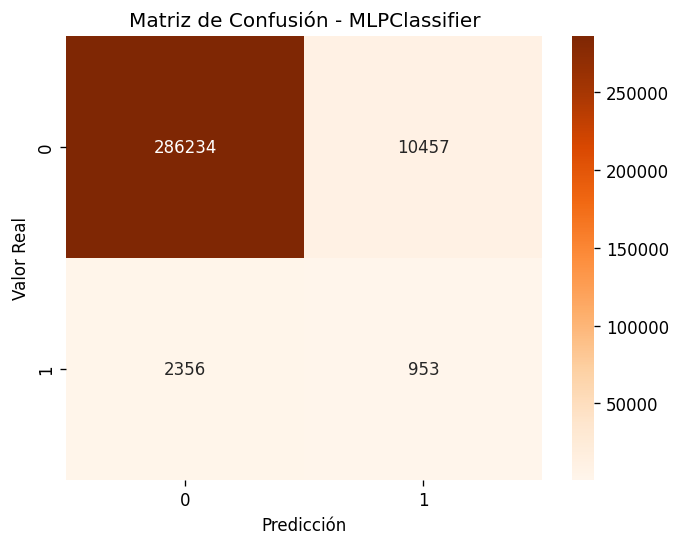

In [17]:
print("Entrenando el pipeline con MLPClassifier...")
pipeline_mlp.fit(X_train, y_train)
print("Entrenamiento completado.")

y_pred_mlp = pipeline_mlp.predict(X_test)

print("\n--- Reporte de Clasificación (MLPClassifier) ---")
print(classification_report(y_test, y_pred_mlp))

print("\n--- Matriz de Confusión (MLPClassifier) ---")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - MLPClassifier')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Entrenando el pipeline con MLPClassifier optimizado...
Entrenamiento completado.

--- Reporte de Clasificación (MLPClassifier optimizes) ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.97    296691
           1       0.08      0.45      0.14      3309

    accuracy                           0.94    300000
   macro avg       0.54      0.70      0.55    300000
weighted avg       0.98      0.94      0.96    300000


--- Matriz de Confusión (MLPClassifier optimized) ---


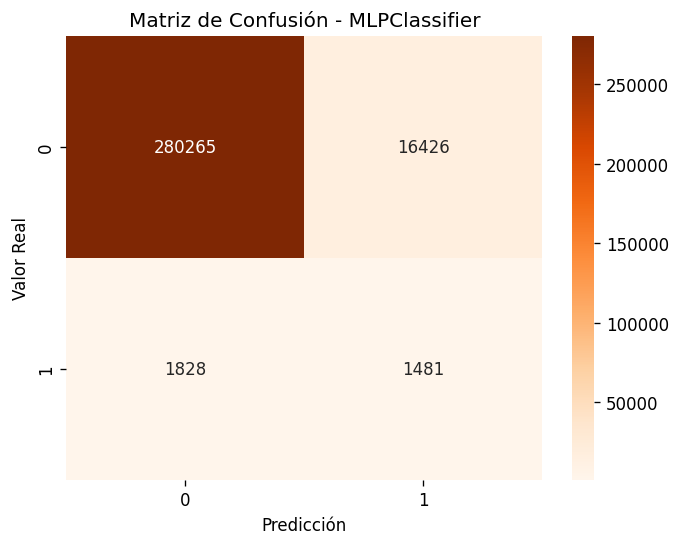

In [13]:
print("Entrenando el pipeline con MLPClassifier optimizado...")
pipeline_mlp_optimizado.fit(X_train, y_train)
print("Entrenamiento completado.")

y_pred_mlp = pipeline_mlp_optimizado.predict(X_test)

print("\n--- Reporte de Clasificación (MLPClassifier optimizes) ---")
print(classification_report(y_test, y_pred_mlp))

print("\n--- Matriz de Confusión (MLPClassifier optimized) ---")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - MLPClassifier')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [17]:
param_dist = {
    'classifier__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64)],
    'classifier__alpha': [1e-5, 1e-4, 1e-3, 1e-2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rnd = RandomizedSearchCV(
    pipeline_mlp_optimizado, param_dist, n_iter=6, cv=cv, scoring='f1',
    n_jobs=-1, random_state=42, refit=True, verbose=0
)

rnd.fit(X_train, y_train)

print("[MLP] Mejores params:", rnd.best_params_)
y_pred_mlp  = rnd.predict(X_test)
y_proba_mlp = rnd.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


[MLP] Mejores params: {'classifier__hidden_layer_sizes': (64,), 'classifier__alpha': 1e-05}


In [18]:
# Exportar modelo como .pkl
import joblib
joblib.dump(rnd.best_estimator_, 'mlp_model.pkl')

['mlp_model.pkl']

In [14]:
def plot_learning_curve(pipe, X, y, title):
    sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, cv=cv, scoring='f1', n_jobs=-1, train_sizes=np.linspace(0.2,1.0,5)
    )
    fig, ax = plt.subplots()
    ax.plot(sizes, train_scores.mean(axis=1), marker='o', label='Train F1')
    ax.plot(sizes, val_scores.mean(axis=1),  marker='s', label='CV F1')
    ax.set_xlabel('Tamaño de entrenamiento'); ax.set_ylabel('F1'); ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

In [19]:
plot_learning_curve(rnd.best_estimator_,  X_train, y_train, 'Learning Curve — MLP')

KeyboardInterrupt: 